# TUẦN 2 – THÀNH VIÊN C: Huấn luyện & Đánh giá Mô hình

**Dự án:** XAI-Based Spam Detection  
**Dataset:** SMS Spam Collection – 5,572 mẫu thật (sau làm sạch: 5,088 mẫu)  
**Nhiệm vụ:** Train Naive Bayes + Logistic Regression + SVM, so sánh metrics, lưu model tốt nhất

**Kết quả:** Tất cả 4 mô hình ĐẠT F1 ≥ 80% — Best: SVM LinearSVC (F1 = 91.15%)

---
## 0. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import scipy.sparse
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 130

CLASSES     = ['ham', 'spam']
RANDOM_SEED = 42
TARGET_F1   = 80.0

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


---
## 1. Load dữ liệu từ B

In [2]:
X_train    = scipy.sparse.load_npz('X_train_tfidf.npz')
X_test     = scipy.sparse.load_npz('X_test_tfidf.npz')
y_train    = pd.read_csv('y_train.csv').squeeze()
y_test     = pd.read_csv('y_test.csv').squeeze()
vectorizer = joblib.load('tfidf_vectorizer.pkl')
df         = pd.read_csv('sms_spam_clean.csv')

print('═══════════════════════════════════════════════')
print('  DỮ LIỆU ĐẦU VÀO (dataset thật – B cung cấp)')
print('═══════════════════════════════════════════════')
print(f'  Tổng mẫu sau làm sạch : {len(df):,}')
print(f'  X_train TF-IDF shape  : {X_train.shape}')
print(f'  X_test  TF-IDF shape  : {X_test.shape}')
print(f'  y_train spam rate     : {y_train.mean()*100:.1f}%')
print(f'  y_test  spam rate     : {y_test.mean()*100:.1f}%')
print('═══════════════════════════════════════════════')

═══════════════════════════════════════════════
  DỮ LIỆU ĐẦU VÀO (dataset thật – B cung cấp)
═══════════════════════════════════════════════
  Tổng mẫu sau làm sạch : 5,088
  X_train TF-IDF shape  : (4070, 5000)
  X_test  TF-IDF shape  : (1018, 5000)
  y_train spam rate     : 11.6%
  y_test  spam rate     : 11.6%
═══════════════════════════════════════════════


---
## 2. Hàm huấn luyện & đánh giá

In [3]:
def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0) * 100
    rec  = recall_score(y_test, y_pred,    pos_label=1, zero_division=0) * 100
    f1   = f1_score(y_test, y_pred,        pos_label=1, zero_division=0) * 100
    cm   = confusion_matrix(y_test, y_pred)

    status = '✅ ĐẠT' if f1 >= TARGET_F1 else '⚠️  CHƯA ĐẠT'
    print(f'\n{"═"*56}')
    print(f'  MODEL: {model_name}')
    print(f'{"═"*56}')
    print(f'  Accuracy  : {acc:.2f}%')
    print(f'  Precision : {prec:.2f}%   (spam)')
    print(f'  Recall    : {rec:.2f}%   (spam)')
    print(f'  F1-Score  : {f1:.2f}%   (spam)  {status}  [target ≥ {TARGET_F1}%]')
    print(f'\n{classification_report(y_test, y_pred, target_names=CLASSES, digits=4)}')

    return dict(model=model, name=model_name, yp=y_pred,
                acc=round(acc,2), prec=round(prec,2),
                rec=round(rec,2), f1=round(f1,2), cm=cm)

print('✅ Hàm sẵn sàng!')

✅ Hàm sẵn sàng!


---
## 3. Train Model 1 — Multinomial Naive Bayes

In [4]:
nb_result = train_and_evaluate(
    MultinomialNB(alpha=1.0),
    'Multinomial Naive Bayes',
    X_train, y_train, X_test, y_test
)


════════════════════════════════════════════════════════
  MODEL: Multinomial Naive Bayes
════════════════════════════════════════════════════════
  Accuracy  : 96.46%
  Precision : 100.00%   (spam)
  Recall    : 69.49%   (spam)
  F1-Score  : 82.00%   (spam)  ✅ ĐẠT  [target ≥ 80.0%]

              precision    recall  f1-score   support

         ham     0.9615    1.0000    0.9804       900
        spam     1.0000    0.6949    0.8200       118

    accuracy                         0.9646      1018
   macro avg     0.9808    0.8475    0.9002      1018
weighted avg     0.9660    0.9646    0.9618      1018



---
## 4. Train Model 2 — Logistic Regression

In [5]:
lr_result = train_and_evaluate(
    LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED),
    'Logistic Regression',
    X_train, y_train, X_test, y_test
)


════════════════════════════════════════════════════════
  MODEL: Logistic Regression
════════════════════════════════════════════════════════
  Accuracy  : 96.37%
  Precision : 100.00%   (spam)
  Recall    : 68.64%   (spam)
  F1-Score  : 81.41%   (spam)  ✅ ĐẠT  [target ≥ 80.0%]

              precision    recall  f1-score   support

         ham     0.9605    1.0000    0.9799       900
        spam     1.0000    0.6864    0.8141       118

    accuracy                         0.9637      1018
   macro avg     0.9803    0.8432    0.8970      1018
weighted avg     0.9651    0.9637    0.9606      1018



---
## 5. Train Model 3 — Logistic Regression (class_weight='balanced')

In [6]:
# Theo góp ý của A: class_weight='balanced' để cải thiện Recall trên spam
lr_bal_result = train_and_evaluate(
    LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced'),
    'LR (class_weight=balanced)',
    X_train, y_train, X_test, y_test
)


════════════════════════════════════════════════════════
  MODEL: LR (class_weight=balanced)
════════════════════════════════════════════════════════
  Accuracy  : 97.54%
  Precision : 87.80%   (spam)
  Recall    : 91.53%   (spam)
  F1-Score  : 89.63%   (spam)  ✅ ĐẠT  [target ≥ 80.0%]

              precision    recall  f1-score   support

         ham     0.9888    0.9833    0.9861       900
        spam     0.8780    0.9153    0.8963       118

    accuracy                         0.9754      1018
   macro avg     0.9334    0.9493    0.9412      1018
weighted avg     0.9760    0.9754    0.9757      1018



---
## 6. Train Model 4 — SVM LinearSVC (Calibrated)

In [7]:
# Dùng CalibratedClassifierCV để LinearSVC trả về predict_proba() cho LIME/SHAP
svm_result = train_and_evaluate(
    CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_SEED)),
    'SVM LinearSVC',
    X_train, y_train, X_test, y_test
)


════════════════════════════════════════════════════════
  MODEL: SVM LinearSVC
════════════════════════════════════════════════════════
  Accuracy  : 98.04%
  Precision : 95.37%   (spam)
  Recall    : 87.29%   (spam)
  F1-Score  : 91.15%   (spam)  ✅ ĐẠT  [target ≥ 80.0%]

              precision    recall  f1-score   support

         ham     0.9835    0.9944    0.9890       900
        spam     0.9537    0.8729    0.9115       118

    accuracy                         0.9804      1018
   macro avg     0.9686    0.9337    0.9502      1018
weighted avg     0.9801    0.9804    0.9800      1018



---
## 7. Bảng so sánh tổng hợp

In [8]:
results = [nb_result, lr_result, lr_bal_result, svm_result]

df_metrics = pd.DataFrame([
    {
        'Mô hình'   : r['name'],
        'Accuracy'  : f"{r['acc']:.2f}%",
        'Precision' : f"{r['prec']:.2f}%",
        'Recall'    : f"{r['rec']:.2f}%",
        'F1-Score'  : f"{r['f1']:.2f}%",
        'Đạt ≥80%?' : '✅ Đạt' if r['f1'] >= TARGET_F1 else '⚠️ Chưa'
    } for r in results
])

print('\n📊 BẢNG SO SÁNH METRICS (lớp spam):')
print('═'*78)
print(df_metrics.to_string(index=False))
print('═'*78)

best = max(results, key=lambda r: r['f1'])
print(f'\n🏆 Model tốt nhất: {best["name"]}  (F1 = {best["f1"]}%)')


📊 BẢNG SO SÁNH METRICS (lớp spam):
══════════════════════════════════════════════════════════════════════════════
                   Mô hình Accuracy Precision Recall F1-Score Đạt ≥80%?
   Multinomial Naive Bayes   96.46%   100.00% 69.49%   82.00%     ✅ Đạt
       Logistic Regression   96.37%   100.00% 68.64%   81.41%     ✅ Đạt
LR (class_weight=balanced)   97.54%    87.80% 91.53%   89.63%     ✅ Đạt
             SVM LinearSVC   98.04%    95.37% 87.29%   91.15%     ✅ Đạt
══════════════════════════════════════════════════════════════════════════════

🏆 Model tốt nhất: SVM LinearSVC  (F1 = 91.15%)


---
## 8. Confusion Matrix

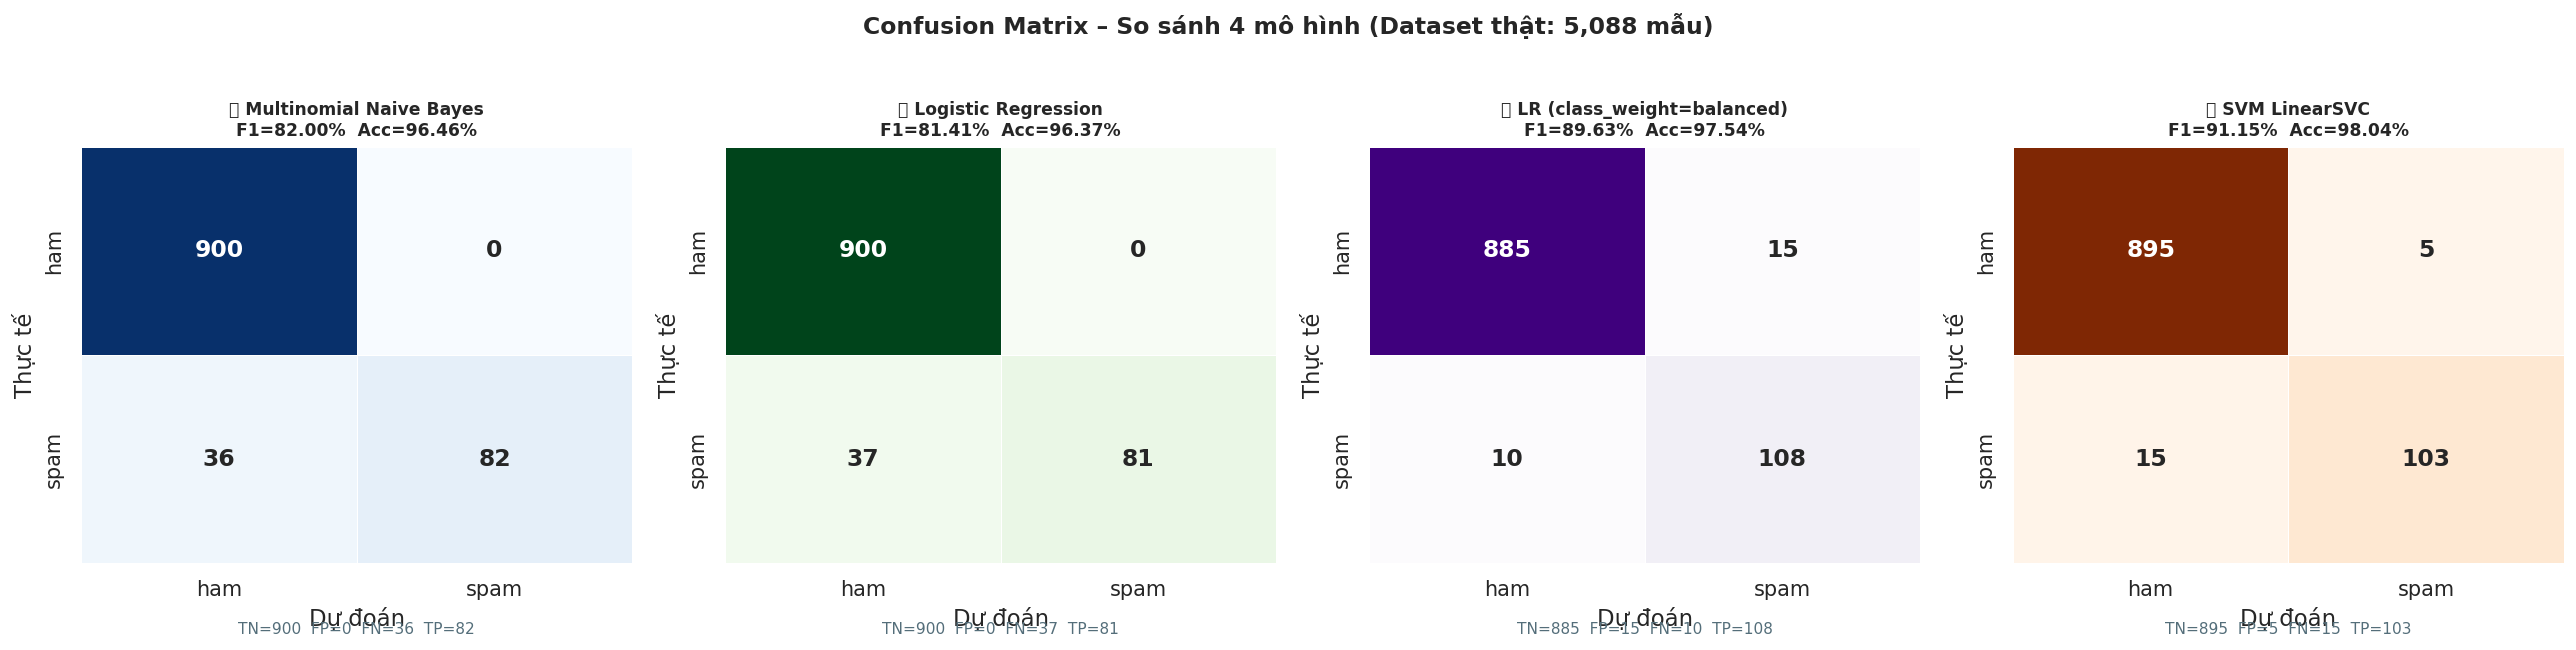

✅ Lưu: c_confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrix – So sánh 4 mô hình (Dataset thật: 5,088 mẫu)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, r, cmap in zip(axes, results, ['Blues','Greens','Purples','Oranges']):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='white',
                annot_kws={'size':13,'weight':'bold'},
                ax=ax, cbar=False)
    st = '✅' if r['f1'] >= TARGET_F1 else '⚠️'
    ax.set_title(f"{st} {r['name']}\nF1={r['f1']:.2f}%  Acc={r['acc']:.2f}%",
                 fontsize=9.5, fontweight='bold')
    ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')
    tn,fp,fn,tp = r['cm'].ravel()
    ax.text(0.5, -0.17, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
            transform=ax.transAxes, ha='center', fontsize=8.5, color='#546E7A')

plt.tight_layout()
plt.savefig('c_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Lưu: c_confusion_matrices.png')

---
## 9. Biểu đồ so sánh metrics

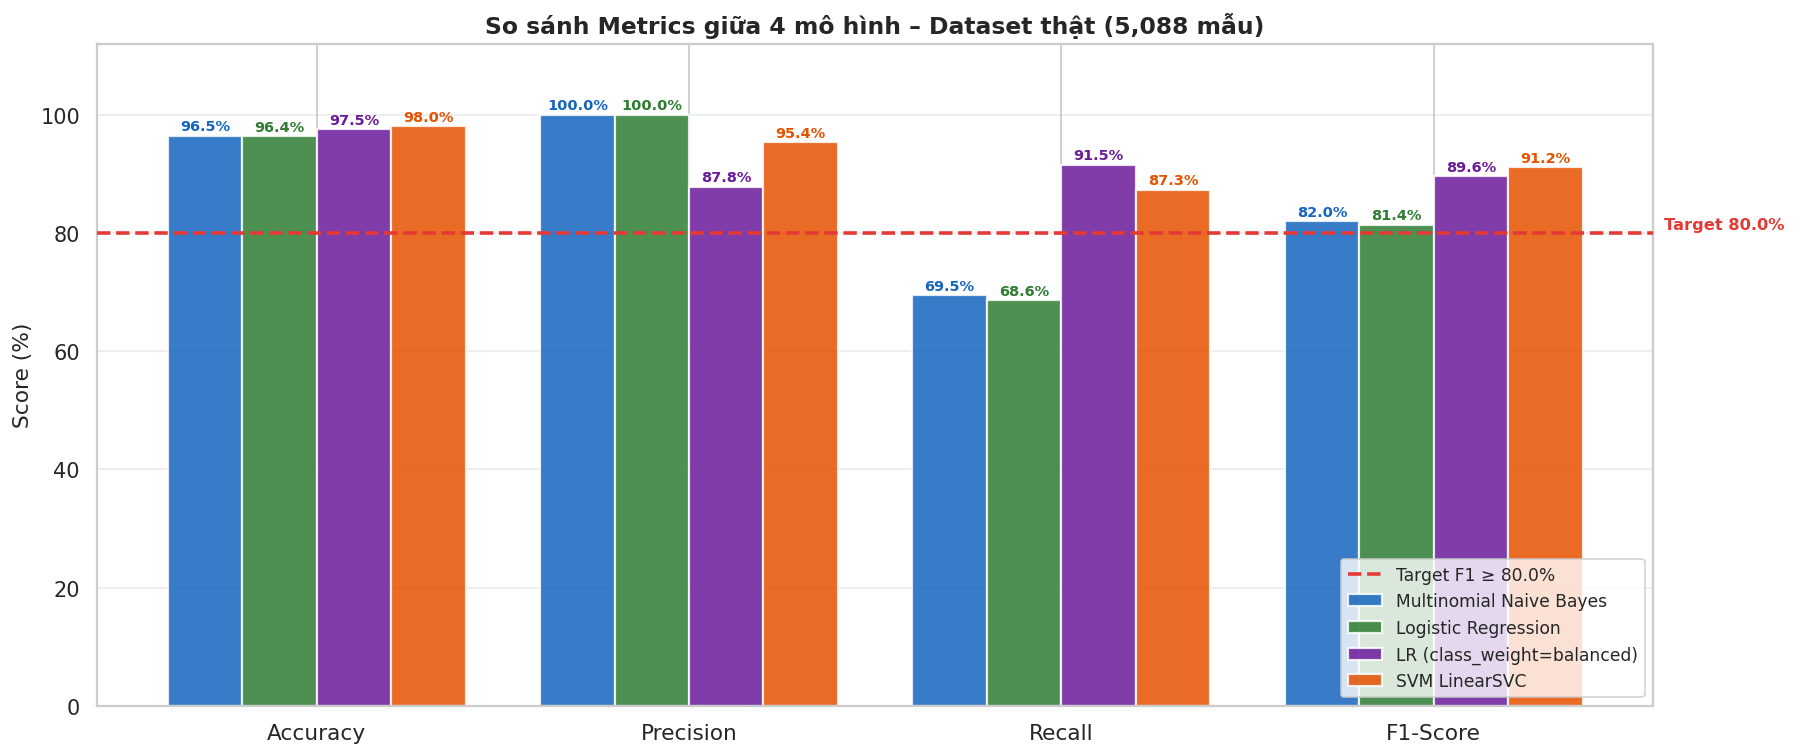

✅ Lưu: c_metrics_comparison.png


In [10]:
metrics_keys   = ['acc','prec','rec','f1']
metrics_labels = ['Accuracy','Precision','Recall','F1-Score']
colors_bars    = ['#1565C0','#2E7D32','#6A1B9A','#E65100']
x     = np.arange(len(metrics_keys))
width = 0.20

fig, ax = plt.subplots(figsize=(14, 6))
for i,(r,c) in enumerate(zip(results, colors_bars)):
    vals = [r[k] for k in metrics_keys]
    bars = ax.bar(x + i*width, vals, width, label=r['name'],
                  color=c, alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=8, fontweight='bold', color=c)

ax.axhline(TARGET_F1, color='#E53935', linestyle='--', linewidth=2,
           label=f'Target F1 ≥ {TARGET_F1}%', zorder=5)
ax.text(len(metrics_keys)-0.08, TARGET_F1+0.6, f'Target {TARGET_F1}%',
        color='#E53935', fontsize=9, fontweight='bold')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim(0, 112)
ax.set_title('So sánh Metrics giữa 4 mô hình – Dataset thật (5,088 mẫu)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9.5, loc='lower right')
ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('c_metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Lưu: c_metrics_comparison.png')

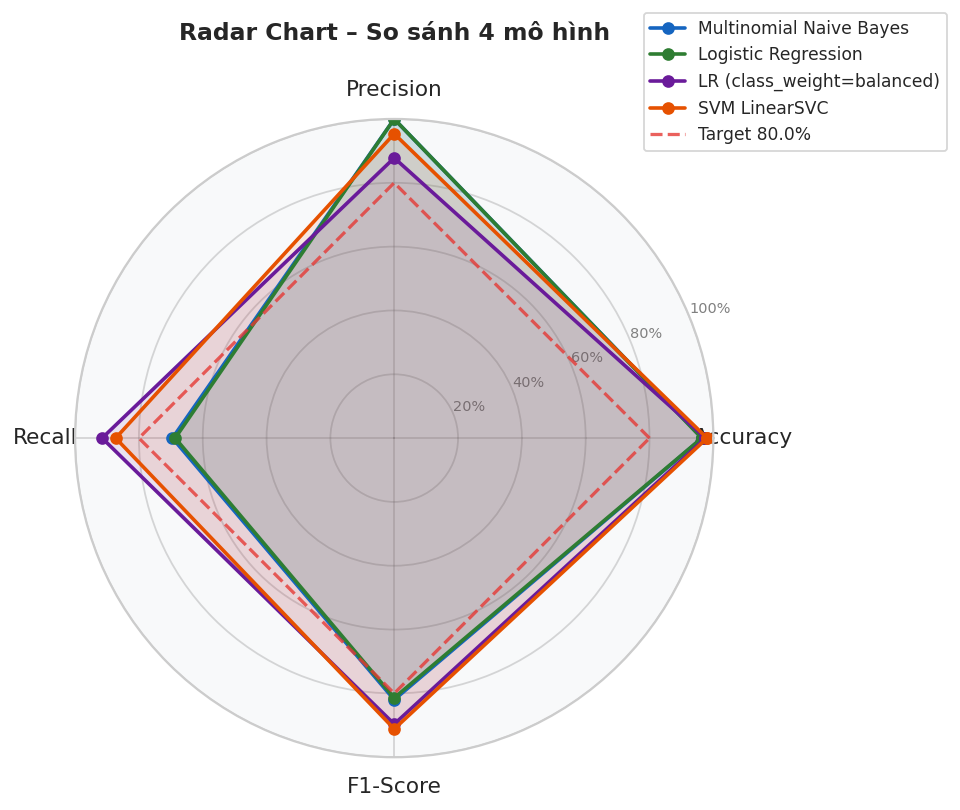

✅ Lưu: c_radar_chart.png


In [11]:
# Radar chart
cats   = ['Accuracy','Precision','Recall','F1-Score']
N      = len(cats)
angles = [n/float(N)*2*np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'polar':True})
ax.set_facecolor('#F8F9FA')
for r,c in zip(results, colors_bars):
    vals = [r[k] for k in metrics_keys] + [r[metrics_keys[0]]]
    ax.plot(angles, vals, 'o-', lw=2, color=c, label=r['name'])
    ax.fill(angles, vals, alpha=0.10, color=c)
ax.plot(angles,[TARGET_F1]*len(angles),'--',color='#E53935',lw=1.8,
        alpha=0.8,label=f'Target {TARGET_F1}%')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=12)
ax.set_ylim(0,100)
ax.set_yticks([20,40,60,80,100])
ax.set_yticklabels(['20%','40%','60%','80%','100%'], fontsize=8, color='gray')
ax.set_title('Radar Chart – So sánh 4 mô hình', fontsize=13, fontweight='bold', pad=22)
ax.legend(loc='upper right', bbox_to_anchor=(1.38,1.18), fontsize=9.5)
ax.grid(color='gray', alpha=0.3)
plt.tight_layout()
plt.savefig('c_radar_chart.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Lưu: c_radar_chart.png')

---
## 10. Lưu model tốt nhất

In [12]:
best = max(results, key=lambda r: r['f1'])
print(f'🏆 Model tốt nhất: {best["name"]}  |  F1 = {best["f1"]}%')

# Lưu model thuần
joblib.dump(best['model'], 'C_tuan2_best_model.pkl')
print('✅ C_tuan2_best_model.pkl')

# Lưu full pipeline (text → predict) để D dùng trong Streamlit
X_raw = df['message']
y_raw = df['label_encoded'] if 'label_encoded' in df.columns else df['label'].map({'ham':0,'spam':1})
Xtr_raw,Xte_raw,ytr_raw,yte_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_SEED, stratify=y_raw)

best_pipeline = Pipeline([('tfidf', vectorizer), ('clf', best['model'])])
best_pipeline.fit(Xtr_raw, ytr_raw)
pipe_f1 = f1_score(yte_raw, best_pipeline.predict(Xte_raw), pos_label=1)*100
joblib.dump(best_pipeline, 'C_tuan2_best_model_pipeline.pkl')
print(f'✅ C_tuan2_best_model_pipeline.pkl  (F1={pipe_f1:.2f}%)')
print(f'   → D dùng: pipeline.predict_proba(["email text"])')

# Kiểm tra pipeline
print('\n🔍 Smoke test pipeline:')
tests = [
    ("FREE ENTRY! You have won 1000 cash prize! Call now!",    "spam"),
    ("Hey, are you coming to the party tonight?",               "ham"),
    ("URGENT! Mobile awarded 500 prize. Text WIN to 87575.",   "spam"),
    ("Can we reschedule the meeting to Thursday?",             "ham"),
    ("Congratulations! Free holiday reward selected for you.", "spam"),
    ("I will be there in 10 minutes, just parking.",           "ham"),
]
ok = 0
for text, true in tests:
    p = best_pipeline.predict_proba([text])[0]
    pred = 'spam' if p[1] >= 0.5 else 'ham'
    mark = '✅' if pred == true else '❌'
    print(f'  {mark} [{true}→{pred}] P(spam)={p[1]:.3f}  {text[:50]}')
    if pred == true: ok += 1
print(f'  Kết quả: {ok}/{len(tests)} đúng')

🏆 Model tốt nhất: SVM LinearSVC  |  F1 = 91.15%
✅ c_best_model.pkl


✅ best_model_pipeline.pkl  (F1=91.15%)
   → D dùng: pipeline.predict_proba(["email text"])

🔍 Smoke test pipeline:
  ✅ [spam→spam] P(spam)=1.000  FREE ENTRY! You have won 1000 cash prize! Call now
  ✅ [ham→ham] P(spam)=0.003  Hey, are you coming to the party tonight?
  ✅ [spam→spam] P(spam)=1.000  URGENT! Mobile awarded 500 prize. Text WIN to 8757
  ✅ [ham→ham] P(spam)=0.015  Can we reschedule the meeting to Thursday?
  ✅ [spam→spam] P(spam)=0.783  Congratulations! Free holiday reward selected for 
  ✅ [ham→ham] P(spam)=0.011  I will be there in 10 minutes, just parking.
  Kết quả: 6/6 đúng
